# Bulk structures, equations of state, and cell relaxation

This notebook follows the [official ASE Bulk Structures and Relaxations tutorial](https://docs.ase-lib.org/examples_generated/03-tutorials/bulk.html). It builds primitive FCC silver, examines its periodic cell, estimates an equilibrium volume and bulk modulus from an equation of state, and relaxes the cell with a force-based optimizer. The final section extends the same tools to a constructed $(6, 3)$ silver nanotube and highlights where a one-dimensional model needs different interpretation.

Unless stated otherwise, distances and cell lengths are in ångström (Å), volumes in Å³, energies in electronvolts (eV), forces in eV/Å, and three-dimensional bulk moduli in gigapascals (GPa). EMT keeps the calculations inexpensive, but its values are model-dependent rather than converged first-principles predictions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ase.build import bulk
from ase.calculators.emt import EMT
from ase.eos import EquationOfState
from ase.filters import FrechetCellFilter
from ase.optimize import BFGS
from ase.units import kJ
from ase.visualize.plot import plot_atoms

## Building primitive FCC silver

`bulk('Ag')` uses ASE's reference crystal structure and lattice parameter to create a one-atom primitive FCC cell. The displayed $3 \times 3 \times 3$ repetition is made only for plotting; it does not replace or enlarge the original `atoms` object.

The reported `FCC(a=4.09)` identifies the Bravais lattice and gives the conventional cubic lattice constant $a = 4.09$ Å. This conventional value is not the length of a primitive cell vector, which is inspected below.

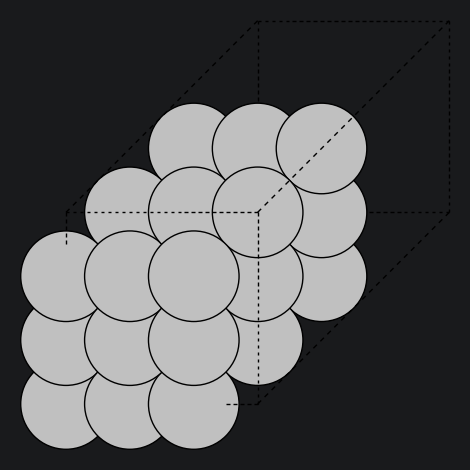

In [2]:
atoms = bulk('Ag')

fig, ax = plt.subplots()
plot_atoms(atoms * (3, 3, 3), ax=ax)
ax.set_xlabel(r'$x (\AA)$')
ax.set_ylabel(r'$y (\AA)$')
fig.tight_layout()

In [3]:
print(f'Bravais lattice: {atoms.cell.get_bravais_lattice()}')

Bravais lattice: FCC(a=4.09)


## Cell vectors and periodicity

The three rows of `atoms.cell` are the primitive lattice vectors. All three periodic-boundary flags are `True`, so translated copies of this one-atom cell tile three-dimensional space. The primitive vectors have equal length $a / \sqrt{2} = 2.892$ Å and mutual angles of $60°$, even though the conventional FCC cell is cubic.

For an FCC primitive cell, the volume is

$$
V_{primitive} = a^3 / 4.
$$

With $a = 4.09$ Å, this gives the printed $V = 17.104$ Å³. Cell lengths, angles, and volume describe the primitive simulation cell, not the plotted repetition.

In [4]:
print('Cell:\n', atoms.cell.round(3))
print('Periodicity: ', atoms.pbc)

Cell:
 [[0.    2.045 2.045]
 [2.045 0.    2.045]
 [2.045 2.045 0.   ]]
Periodicity:  [ True  True  True]


In [5]:
print('Cell lengths:\n', atoms.cell.lengths())
print('Cell angles:\n', atoms.cell.angles())
print('Cell volume:\n', atoms.cell.volume)

Cell lengths:
 [2.89206674 2.89206674 2.89206674]
Cell angles:
 [60. 60. 60.]
Cell volume:
 17.104482249999997


## Equation of state for bulk Ag

An equation-of-state calculation samples the potential energy as the cell is compressed and expanded. Each loop iteration copies the reference structure, attaches EMT, and multiplies every lattice vector by a scale factor $x$ from 0.95 to 1.05. Because `scale_atoms=True`, Cartesian positions change with the cell while fractional coordinates are preserved. The isotropic scaling gives

$$
V(x) = x^3 V_{reference}.
$$

`EquationOfState` fits the sampled $E(V)$ data and returns the equilibrium volume $V_0$, minimum energy $E_0$, and bulk modulus

$$
B = V_0 (d^2 E / dV^2)_{V_0}.
$$

The saved fit gives $V_0 = 16.776$ Å³, $E_0 \approx 0$ eV, and $B = 100.124$ GPa. The near-zero minimum energy reflects EMT's energy reference; only energy differences are physically useful here. The conversion through `kJ` changes ASE's internal pressure unit of eV/Å³ to GPa.

In [6]:
calc = EMT()
cell = atoms.get_cell()

volumes = []
energies = []
for x in np.linspace(0.95, 1.05, 5):
    atoms_copy = atoms.copy()
    atoms_copy.calc = calc
    atoms_copy.set_cell(cell * x, scale_atoms=True)
    atoms_copy.get_potential_energy()
    volumes.append(atoms_copy.get_volume())
    energies.append(atoms_copy.get_potential_energy())

Minimum Volume = 16.776AA^3
Minimum Energy = -0.000eV
Bulk modulus   = 100.124 GPa


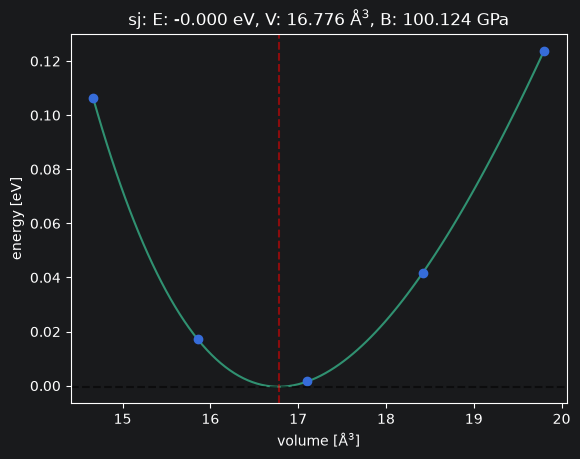

In [7]:
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

ax = eos.plot()
ax.axhline(e0, linestyle='--', alpha=0.5, color='black')
ax.axvline(v0, linestyle='--', alpha=0.5, color='red')

print(f'Minimum Volume = {v0:.3f}AA^3')
print(f'Minimum Energy = {e0:.3f}eV')
print(f'Bulk modulus   = {B / kJ * 1.0e24:.3f} GPa')
plt.show()

## Variable-cell relaxation of bulk Ag

`FrechetCellFilter(atoms)` presents the atomic coordinates and cell degrees of freedom to BFGS as one optimizable object. BFGS can therefore respond to both atomic forces and cell stress instead of keeping the lattice fixed. For this one-atom primitive FCC model, the cell change is the important degree of freedom.

The run stops when the largest generalized force reported by the filtered optimization falls below $0.01$ eV/Å. The saved calculation reaches `fmax = 0.0031` eV/Å, preserves the FCC symmetry, and changes the conventional lattice constant from 4.090 to 4.063 Å. Its final primitive-cell volume, 16.770 Å³, closely agrees with the EOS minimum of 16.776 Å³. This agreement is a useful internal check for the same EMT model and starting structure.

In [8]:
original_lattice = atoms.cell.get_bravais_lattice()
calc = EMT()
atoms.calc = calc

opt = BFGS(FrechetCellFilter(atoms), trajectory='../files/advanced/tutorial_01/opt_Ag.traj')
opt.run(fmax=0.01)
print('\n')
print(f'Original_Lattice:   {original_lattice}')
print(f'Final Lattice:      {atoms.cell.get_bravais_lattice()}')
print(f'Final Cell Volume:  {atoms.get_volume():.3f}AA^3')

      Step     Time          Energy          fmax
BFGS:    0 12:59:13        0.001584        0.198735
BFGS:    1 12:59:13        0.000255        0.113074
BFGS:    2 12:59:13       -0.000366        0.003126


Original_Lattice:   FCC(a=4.09)
Final Lattice:      FCC(a=4.06315)
Final Cell Volume:  16.770AA^3


## Extending the workflow to a constructed Ag nanotube

`nanotube(6, 3, symbol='Ag')` uses the chiral indices $(n, m) = (6, 3)$ to construct a single periodic tube repeat and changes the atomic symbols to Ag. The generator still uses its default nearest-neighbor bond length of 1.42 Å, which is a carbon-nanotube-like value and is much shorter than the 2.892 Å Ag–Ag nearest-neighbor distance implied by the FCC model above. The resulting high energies and forces should therefore be interpreted as relaxation away from an intentionally strained starting geometry, not as evidence for a realistic silver nanotube.

The initial cell is periodic only along its $z$ vector. ASE consequently identifies it as `LINE(a=11.2709)`: the two transverse cell vectors have zero length, the axial repeat is 11.271 Å, and the three-dimensional cell volume is exactly zero. The plotting rotation changes only the view of the structure.

In [9]:
from ase.build import nanotube

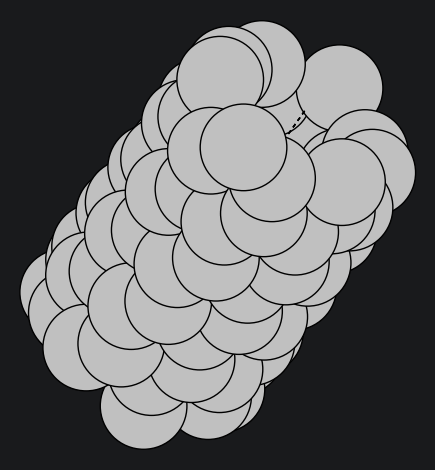

In [10]:
atoms = nanotube(6, 3, symbol='Ag')

fig, ax = plt.subplots()
plot_atoms(atoms, ax=ax, rotation='-45x,45y,0z')
ax.set_xlabel(r'$x (\AA)$')
ax.set_ylabel(r'$y (\AA)$')
fig.tight_layout()

In [11]:
print(f'Bravais lattice: {atoms.cell.get_bravais_lattice()}')

Bravais lattice: LINE(a=11.2709)


In [12]:
print('Cell lengths:\n', atoms.cell.lengths())
print('Cell angles:\n', atoms.cell.angles())
print('Cell volume:\n', atoms.cell.volume)

Cell lengths:
 [ 0.          0.         11.27090059]
Cell angles:
 [90. 90. 90.]
Cell volume:
 0.0


### Axial energy scan

The loop scales only the third cell vector from $0.50 L_0$ to $2.50 L_0$. With `scale_atoms=True`, the atomic $z$ coordinates scale with the axial repeat, while the tube radius and all transverse coordinates remain fixed. No atomic relaxation is performed at any sampled length, so this is an unrelaxed one-dimensional strain scan.

> **Dimensionality caveat:** `EquationOfState` is designed to fit energy as a function of three-dimensional volume, but the next cell passes axial lengths in Å. Its fitted value of 25.385 Å can only be treated as a heuristic minimum of this length-based dataset. The returned `B` parameter is interpreted internally as a volume-derived bulk modulus, so converting it to the printed 34,404.385 GPa is dimensionally invalid and the number is not a physical bulk modulus. The zero transverse cell volume reinforces that a three-dimensional bulk modulus is undefined for this model.

A meaningful length analysis would relax the internal coordinates at every fixed $L$, fit $E(L)$ near its minimum, and report the axial curvature

$$
k_L = (d^2 E / dL^2)_{L_0}.
$$

Converting that curvature to a three-dimensional Young's modulus additionally requires an explicit, justified effective cross-sectional area for the hollow tube.

In [13]:
calc = EMT()

cell = atoms.get_cell().copy()

lengths = []
energies = []

for x in np.linspace(0.50, 2.50, 30):
    atoms_copy = atoms.copy()
    atoms_copy.calc = calc

    new_cell = cell.copy()
    new_cell[2] *= x

    atoms_copy.set_cell(new_cell, scale_atoms=True)

    lengths.append(np.linalg.norm(new_cell[2]))
    energies.append(atoms_copy.get_potential_energy())

Minimum Length = 25.385AA
Minimum Energy = 1209.273eV
Bulk modulus   = 34404.385 GPa


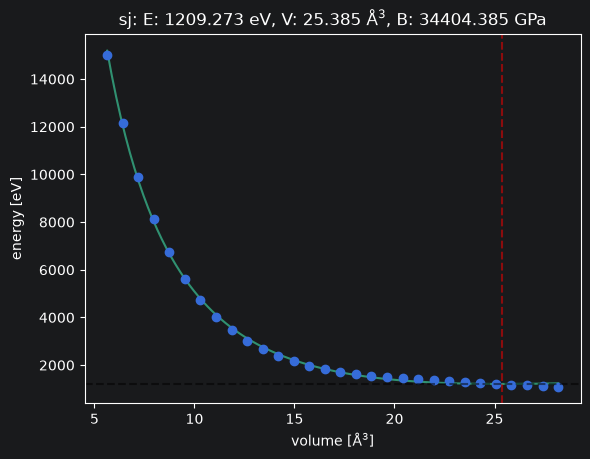

In [14]:
eos = EquationOfState(lengths, energies)
v0, e0, B = eos.fit()

ax = eos.plot()
ax.axhline(e0, linestyle='--', alpha=0.5, color='black')
ax.axvline(v0, linestyle='--', alpha=0.5, color='red')

print(f'Minimum Length = {v0:.3f}AA')
print(f'Minimum Energy = {e0:.3f}eV')
print(f'Bulk modulus   = {B / kJ * 1.0e24:.3f} GPa')
plt.show()

### Axial cell and atomic relaxation

`center(vacuum=10.0, axis=(0, 1))` creates finite transverse cell vectors with 10 Å of vacuum around the isolated directions. Setting `pbc = [False, False, True]` then keeps periodic images connected only along the tube axis.

The six-component filter mask follows `[xx, yy, zz, yz, xz, xy]`; only the `zz` cell strain is enabled. This restriction fixes the transverse cell and all shear components, but it does **not** freeze the atoms: every atomic coordinate remains free to relax. The BFGS `fmax` value is therefore the largest generalized force across the allowed atomic and cell degrees of freedom.

The saved run reaches `fmax = 0.0081` eV/Å at step 57. The axial repeat grows from 11.271 to 12.193 Å, corresponding to an 8.18% strain relative to the starting cell, while the EMT energy falls from 3869.017 to 43.625 eV. Because the starting bond length is strongly compressed and all atoms can reconstruct, optimizer convergence alone does not show that the final object retained a nanotube geometry or represents stable Ag. The trajectory should be inspected before drawing a structural conclusion.

In [15]:
# Add vacuum in the non-periodic x and y directions
atoms.center(vacuum=10.0, axis=(0, 1))

# Keep periodicity only along the nanotube axis
atoms.pbc = [False, False, True]

# Original axial lattice length
original_length = np.linalg.norm(atoms.cell[2])

calc = EMT()
atoms.calc = calc

# Only allow zz strain:
# [xx, yy, zz, yz, xz, xy]
cell_filter = FrechetCellFilter(
    atoms,
    mask=[False, False, True, False, False, False]
)

opt = BFGS(
    cell_filter,
    trajectory='../files/advanced/tutorial_01/opt_Ag_nanotube.traj'
)

opt.run(fmax=0.01)

final_length = np.linalg.norm(atoms.cell[2])

print()
print(f'Original axial length: {original_length:.3f} Å')
print(f'Final axial length:    {final_length:.3f} Å')
print(f'Strain:                {(final_length / original_length - 1) * 100:.2f} %')

      Step     Time          Energy          fmax
BFGS:    0 12:59:14     3869.016621      102.380067
BFGS:    1 12:59:14     3673.694577      102.926921
BFGS:    2 12:59:14     3487.250294       95.049540
BFGS:    3 12:59:14     3255.719375       86.833844
BFGS:    4 12:59:14     3007.577366       78.848692
BFGS:    5 12:59:14     2684.477276       68.028290
BFGS:    6 12:59:14     2248.787880       54.354396
BFGS:    7 12:59:14     1866.569112       43.138026
BFGS:    8 12:59:14     1534.401920       34.121228
BFGS:    9 12:59:14     1248.423238       26.970442
BFGS:   10 12:59:14     1004.740762       21.381559
BFGS:   11 12:59:14      799.698664       17.085144
BFGS:   12 12:59:14      629.656853       13.840602
BFGS:   13 12:59:14      490.858112       11.443144
BFGS:   14 12:59:14      379.642727        9.689993
BFGS:   15 12:59:14      292.383328        8.408123
BFGS:   16 12:59:14      225.481305        7.461299
BFGS:   17 12:59:14      175.362640        6.731666
BFGS:   18 12:

## Takeaways and possible extensions

The bulk workflow provides two complementary equilibrium checks: fit an isotropic $E(V)$ curve and minimize the filtered atomic-plus-cell degrees of freedom. For FCC Ag with EMT, the fitted and optimized primitive volumes agree to within about 0.006 Å³. The calculation also shows why a conventional FCC lattice constant, primitive-vector length, and primitive-cell volume must be distinguished.

The nanotube extension illustrates the limits of reusing a three-dimensional method. A periodic line cell has no intrinsic three-dimensional volume, so a bulk EOS fit and GPa conversion cannot be applied directly to $E(L)$. Useful follow-up work includes choosing and documenting a material-appropriate starting bond length, relaxing the internal coordinates at each axial length, fitting only points near the minimum, reporting a one-dimensional axial stiffness, and testing any effective-area convention separately. For both models, compare calculators and numerical settings before treating the results as quantitative material predictions.